# FEATURE SELECTION - VN INDEX

## Import libraries

In [99]:
import os
import sys
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, EfficientFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname
from sklearn.inspection import permutation_importance
import xgboost as xgb
import seaborn as sns
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import *
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from ta.ta_functions import *

## Helper functions

In [100]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [101]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 5
COLUMN_ID = "stock"
TARGET_COLUMN = "return_5"
DATE_COLUMN = "date"
FEATURE_COLUMNS = []  # all TA indicators

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [102]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Load data

In [103]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [104]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [105]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [106]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [107]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "adjust": float,
    "change": float,
    "percent_change": float,
    "matching_volume": float,
    "matching_value": float,
    "negotiate_volume": float,
    "negotiate_value": float,
    "number_of_buy_orders": float,
    "buy_volume": float,
    "average_volume_per_buy_order": float,
    "number_of_sell_orders": float,
    "sell_volume": float,
    "average_volume_per_sell_order": float,
    "net_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [108]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970000,4.740000,8.169220e+06,5.152538e+11,350040.0,2.910304e+10,26816.0,5.268141e+07,1965.000000,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.190,25.363333,4.106667,1.314382e+07,8.298321e+11,769057.0,4.594466e+10,27442.0,5.068024e+07,1852.333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.240,21.756667,3.473333,1.811842e+07,1.144410e+12,1188073.0,6.278627e+10,28068.0,4.867907e+07,1739.666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150000,2.840000,2.309302e+07,1.458989e+12,1607090.0,7.962789e+10,28694.0,4.667790e+07,1627.000000,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580000,-2.970000,1.384280e+07,8.374665e+11,226000.0,1.209960e+10,14464.0,1.933131e+07,1337.000000,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.445000,1.837000,7.158068e+08,2.227241e+13,23581058.0,7.924402e+11,476711.0,1.233848e+09,2591.300000,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.140,36.050000,1.980000,7.313611e+08,2.264621e+13,23192200.0,7.774309e+11,486603.0,1.253004e+09,2575.000000,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.620,7.480000,0.400000,9.667547e+08,3.120594e+13,22413147.0,7.795734e+11,598087.0,1.575227e+09,2634.000000,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.910,-6.710000,-0.360000,1.083635e+09,3.567852e+13,62225450.0,1.856894e+12,694266.0,1.862364e+09,2682.000000,597096.0,1.892734e+09,3170.0,-3.036983e+07


## Data transformation

In [109]:
vn_index_df.shape

(6566, 19)

### Remove DAYOFFS

In [110]:
vn_index_df_t1 = vn_index_df[~vn_index_df["date"].isin(DAYOFFS)]
vn_index_df_t1.shape

(4690, 19)

### Calculate return

In [111]:
vn_index_df_t2 = vn_index_df_t1.copy()
vn_index_df_t2[f"return_{FORECAST_HORIZON}"] = (
    vn_index_df_t2["close"].shift(-FORECAST_HORIZON) - vn_index_df_t1["close"]
)
# vn_index_df_t2[f"log_return_{FORECAST_HORIZON}"] = np.log(
#     vn_index_df_t2["close"].shift(-FORECAST_HORIZON) / vn_index_df_t2["close"]
# )
vn_index_df_t2 = vn_index_df_t2.dropna(how="any").reset_index(drop=True)
vn_index_df_t2.shape

(4685, 20)

In [112]:
vn_index_df_t_final = vn_index_df_t2
vn_index_df_t_final.shape

(4685, 20)

## Create features

In [113]:
FUNCTION_NAME = "add_bbands"
FUNCTION_NAME

'add_bbands'

In [114]:
vn_index_df_cf1 = add_bbands(vn_index_df_t_final, n=[5, 10, 15, 20])
vn_index_df_cf1.shape

(4685, 112)

In [115]:
vn_index_df_cf_final = vn_index_df_cf1
vn_index_df_cf_final.shape

(4685, 112)

## Filter columns

In [116]:
FEATURE_COLUMNS = list(
    vn_index_df_cf_final.columns.drop(
        [
            DATE_COLUMN,
            TARGET_COLUMN,
        ]
    )
)
len(FEATURE_COLUMNS)

110

## Feature Importance

In [117]:
input_df = vn_index_df_cf_final
input_df.shape

(4685, 112)

In [118]:
TOP_N = 50

In [119]:
len(FEATURE_COLUMNS)

110

In [120]:
TARGET_COLUMN

'return_5'

### Model

In [134]:
n_estimators = 1000
max_depth = 16
learning_rate = 0.05
subsample = 0.8
colsample_bytree = 0.8
tree_method = "hist"
n_repeats = 40

In [ ]:
# -----------------------------
# CONFIG
# -----------------------------
np.random.seed(RANDOM_SEED)

# -----------------------------
# PREPARE DATA
# -----------------------------
input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])

X = input_df[FEATURE_COLUMNS]
y = input_df[TARGET_COLUMN]

# -----------------------------
# GPU XGBOOST MODEL
# -----------------------------
model = xgb.XGBRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    tree_method="hist",  # required for GPU
    device="cuda",
    random_state=RANDOM_SEED,
)

model.fit(X, y, verbose=True)

# -----------------------------
# BASELINE (GPU prediction)
# -----------------------------
baseline_pred = model.predict(X)
baseline_mse = np.mean((y - baseline_pred) ** 2)

# -----------------------------
# GPU PERMUTATION IMPORTANCE + PROGRESS
# -----------------------------
importances = []

for col in tqdm(X.columns, desc="Permutation Importance"):
    scores = []

    for _ in range(n_repeats):
        X_permuted = X.copy()
        X_permuted[col] = np.random.permutation(X_permuted[col].values)

        pred = model.predict(X_permuted)  # runs on GPU
        mse = np.mean((y - pred) ** 2)

        scores.append(mse)

    importance = np.mean(scores) - baseline_mse
    importances.append(importance)

# -----------------------------
# CREATE IMPORTANCE DF
# -----------------------------
importance_df = pd.DataFrame(
    {"feature": X.columns, "importance": importances}
).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
)

# -----------------------------
# OUTPUT
# -----------------------------
print("\nFeature Importance:")
print(importance_df)

In [ ]:
importance_df

,feature,importance,importance_pct
13,average_volume_per_buy_order,15.452966,18.454862
41,close_bb_10_upper,11.402896,13.618025
89,close_bb_20_lower,8.894230,10.622024
12,buy_volume,4.225511,5.046360
56,close_bb_10_pct_b,3.281691,3.919193
...,...,...,...
54,close_bb_10_bandwidth_slope,0.000000,0.000000
53,close_bb_10_bandwidth,0.000000,0.000000
109,close_bb_20_position,0.000000,0.000000
14,number_of_sell_orders,-0.187478,-0.223898


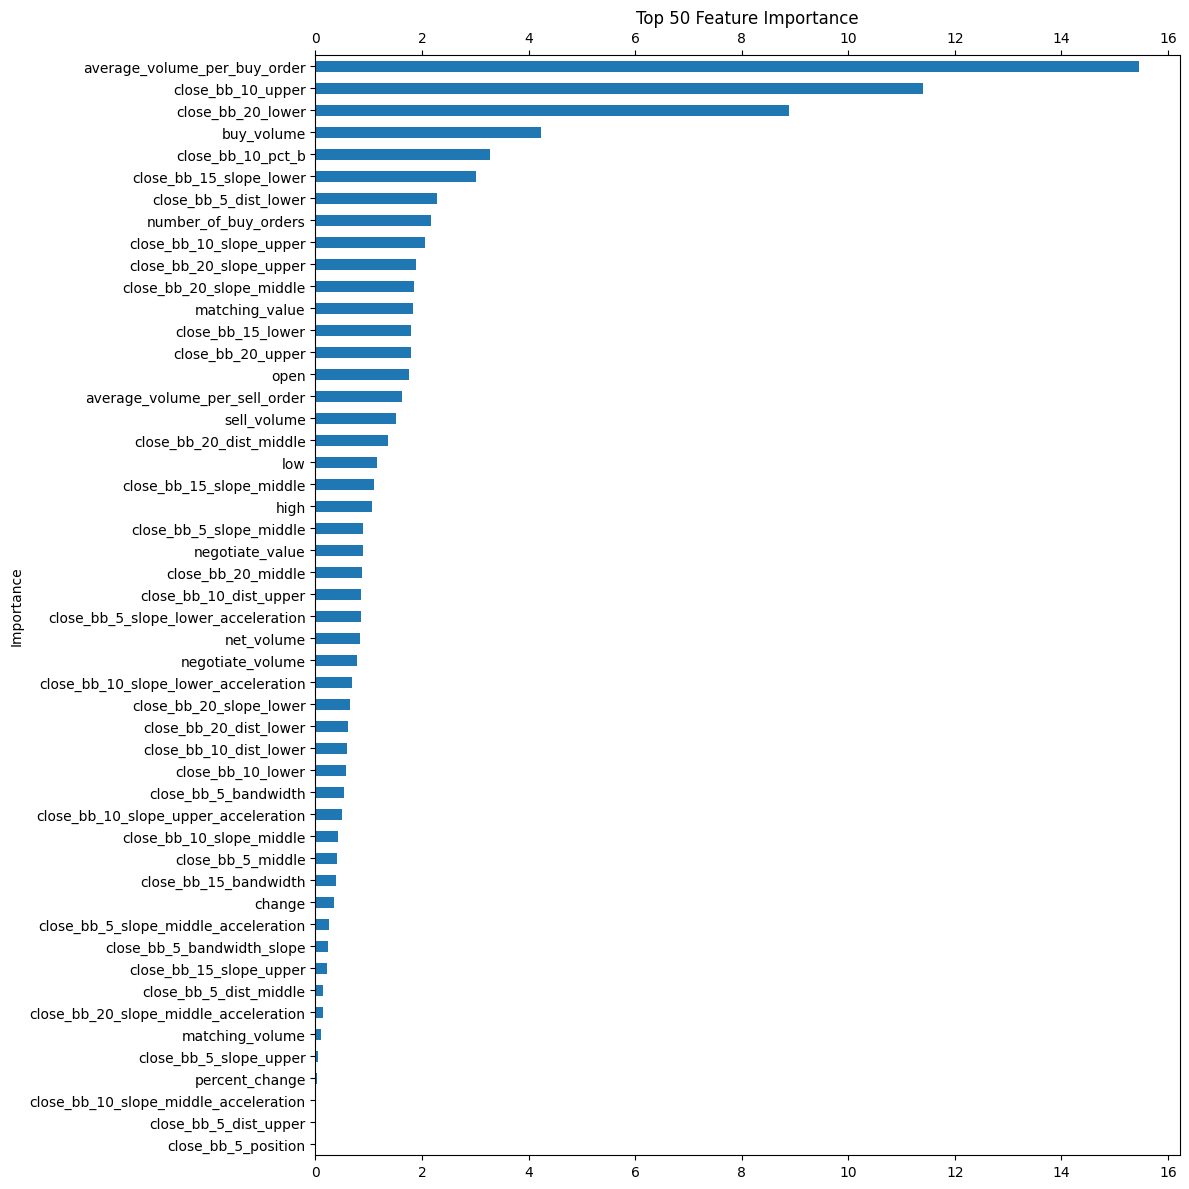

In [ ]:
top_features = (
    importance_df.sort_values("importance", ascending=False)
    .head(TOP_N)
    .set_index("feature")["importance"]
).sort_values(ascending=True)

# Plot
ax = top_features.plot(kind="barh", figsize=(12, 12))

plt.title(f"Top {TOP_N} Feature Importance")
plt.ylabel("Importance")

# Show x ticks on both top and bottom
ax.xaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", top=True, bottom=True, labeltop=True)

plt.tight_layout()
plt.show()

In [ ]:
TOP_N_FEATURES = list(top_features.index)
TOP_N_FEATURES

['close_bb_5_position',
 'close_bb_5_dist_upper',
 'close_bb_10_slope_middle_acceleration',
 'percent_change',
 'close_bb_5_slope_upper',
 'matching_volume',
 'close_bb_20_slope_middle_acceleration',
 'close_bb_5_dist_middle',
 'close_bb_15_slope_upper',
 'close_bb_5_bandwidth_slope',
 'close_bb_5_slope_middle_acceleration',
 'change',
 'close_bb_15_bandwidth',
 'close_bb_5_middle',
 'close_bb_10_slope_middle',
 'close_bb_10_slope_upper_acceleration',
 'close_bb_5_bandwidth',
 'close_bb_10_lower',
 'close_bb_10_dist_lower',
 'close_bb_20_dist_lower',
 'close_bb_20_slope_lower',
 'close_bb_10_slope_lower_acceleration',
 'negotiate_volume',
 'net_volume',
 'close_bb_5_slope_lower_acceleration',
 'close_bb_10_dist_upper',
 'close_bb_20_middle',
 'negotiate_value',
 'close_bb_5_slope_middle',
 'high',
 'close_bb_15_slope_middle',
 'low',
 'close_bb_20_dist_middle',
 'sell_volume',
 'average_volume_per_sell_order',
 'open',
 'close_bb_20_upper',
 'close_bb_15_lower',
 'matching_value',
 'cl

## Feature Selection

In [ ]:
CORR_THRESHOLD = 0.95

# Correlation matrix (absolute values)
corr_matrix = input_df[FEATURE_COLUMNS].corr().abs()

# Features sorted by importance
sorted_features = importance_df.sort_values("importance", ascending=False)[
    "feature"
].tolist()

selected_features = []
removed_features = set()

for feature in sorted_features:

    if feature in removed_features:
        continue

    selected_features.append(feature)

    # Find correlated features
    correlated = corr_matrix.index[corr_matrix[feature] > CORR_THRESHOLD].tolist()

    for corr_feature in correlated:
        if corr_feature != feature:
            removed_features.add(corr_feature)

print("Selected features:", len(selected_features))
print("Removed features:", len(removed_features))

print("\nTop kept features:")
print(selected_features[:TOP_N])

print("\nRemoved features:")
print(list(removed_features))

Selected features: 79
Removed features: 31

Top kept features:
['average_volume_per_buy_order', 'close_bb_10_upper', 'buy_volume', 'close_bb_10_pct_b', 'close_bb_15_slope_lower', 'close_bb_5_dist_lower', 'number_of_buy_orders', 'close_bb_10_slope_upper', 'close_bb_20_slope_upper', 'close_bb_20_slope_middle', 'matching_value', 'average_volume_per_sell_order', 'close_bb_20_dist_middle', 'close_bb_15_slope_middle', 'close_bb_5_slope_middle', 'negotiate_value', 'close_bb_10_dist_upper', 'close_bb_5_slope_lower_acceleration', 'net_volume', 'negotiate_volume', 'close_bb_10_slope_lower_acceleration', 'close_bb_20_slope_lower', 'close_bb_20_dist_lower', 'close_bb_10_dist_lower', 'close_bb_5_bandwidth', 'close_bb_10_slope_upper_acceleration', 'close_bb_10_slope_middle', 'close_bb_15_bandwidth', 'change', 'close_bb_5_slope_middle_acceleration', 'close_bb_5_bandwidth_slope', 'close_bb_15_slope_upper', 'close_bb_5_dist_middle', 'close_bb_20_slope_middle_acceleration', 'close_bb_5_slope_upper', 'pe

## Feature Correlation

Correlation Matrix:


,average_volume_per_buy_order,close_bb_10_upper,buy_volume,close_bb_10_pct_b,close_bb_15_slope_lower,close_bb_5_dist_lower,number_of_buy_orders,close_bb_10_slope_upper,close_bb_20_slope_upper,close_bb_20_slope_middle,...,close_bb_5_slope_lower,close_bb_10_below_lower,close_bb_5_bandwidth_acceleration,close_bb_5_pct_b_slope,close_bb_5_pct_b_gt_1,close_bb_10_dist_middle,close_bb_15_dist_upper,close_bb_10_position,close_bb_10_slope_lower,close_bb_10_inside_bands
average_volume_per_buy_order,1.000000,-0.097836,0.186018,0.224991,0.067250,-0.011279,-0.131189,0.115211,0.137811,0.156898,...,0.090043,-0.088526,-0.006214,0.071048,NaN,0.189459,0.283797,0.117811,0.080615,0.018526
close_bb_10_upper,-0.097836,1.000000,0.741258,0.053381,0.038129,-0.112508,0.850466,0.061910,0.110466,0.131240,...,0.018653,0.016324,-0.002249,-0.004385,NaN,0.011766,0.137241,-0.020527,0.023708,-0.002810
buy_volume,0.186018,0.741258,1.000000,0.112241,0.087482,-0.011732,0.867250,0.140435,0.191092,0.220855,...,0.052982,0.007568,0.002015,-0.019703,NaN,0.087143,0.139480,0.006831,0.076872,-0.013330
close_bb_10_pct_b,0.224991,0.053381,0.112241,1.000000,0.381611,0.437636,0.046928,0.366374,0.268618,0.457223,...,0.507048,-0.426110,-0.015441,0.130017,NaN,0.813368,0.617669,0.522232,0.470359,0.087615
close_bb_15_slope_lower,0.067250,0.038129,0.087482,0.381611,1.000000,-0.018665,0.064711,0.074557,-0.044938,0.546432,...,0.423403,-0.264535,-0.012700,-0.021494,NaN,0.494880,0.507848,0.175675,0.662952,0.210132
close_bb_5_dist_lower,-0.011279,-0.112508,-0.011732,0.437636,-0.018665,1.000000,-0.050311,0.211039,0.140160,0.072410,...,0.190249,-0.160280,-0.114945,0.172316,NaN,0.489410,-0.008071,0.291422,0.031411,-0.065680
number_of_buy_orders,-0.131189,0.850466,0.867250,0.046928,0.064711,-0.050311,1.000000,0.092805,0.132010,0.163864,...,0.010591,0.041813,0.007998,-0.047375,NaN,0.038603,0.106474,-0.032265,0.044555,-0.023314
close_bb_10_slope_upper,0.115211,0.061910,0.140435,0.366374,0.074557,0.211039,0.092805,1.000000,0.450420,0.464988,...,-0.018489,0.153903,0.064152,-0.029491,NaN,0.404208,0.495641,0.060924,-0.200763,-0.293293
close_bb_20_slope_upper,0.137811,0.110466,0.191092,0.268618,-0.044938,0.140160,0.132010,0.450420,1.000000,0.604403,...,0.037031,0.011871,0.002111,-0.014835,NaN,0.247992,0.245709,0.089373,0.013541,-0.111414
close_bb_20_slope_middle,0.156898,0.131240,0.220855,0.457223,0.546432,0.072410,0.163864,0.464988,0.604403,1.000000,...,0.296221,-0.137648,0.001300,-0.024772,NaN,0.533820,0.629019,0.179600,0.437057,0.016863


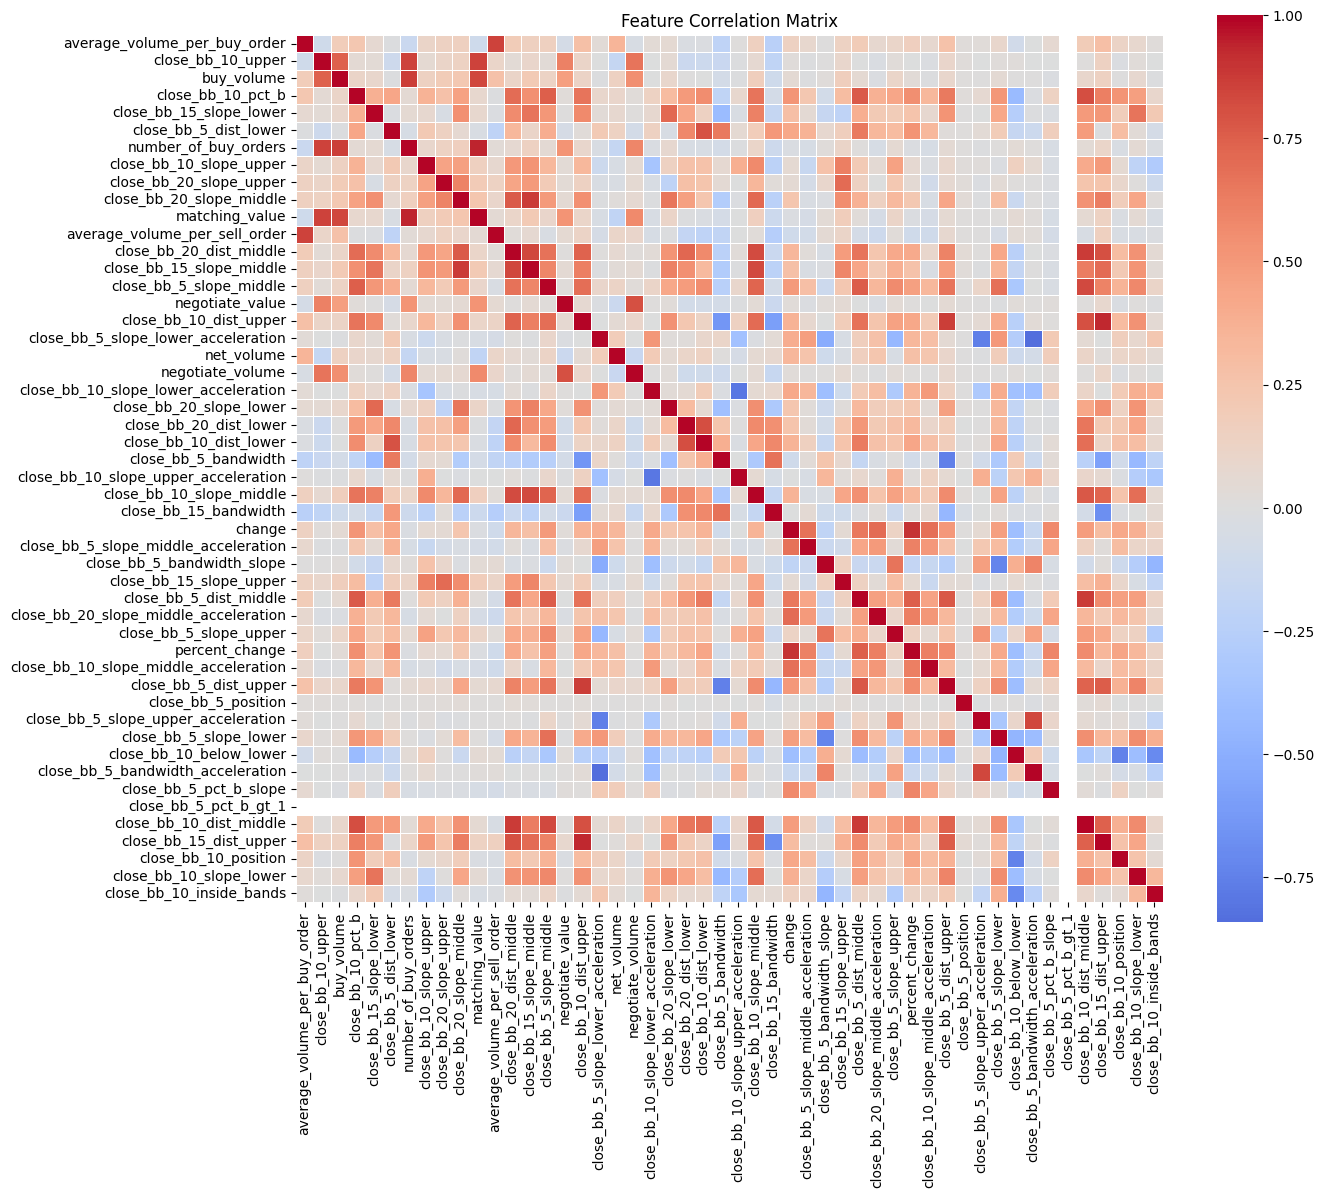

In [ ]:
corr_matrix = input_df[selected_features[:TOP_N]].corr()

print("Correlation Matrix:")
display(corr_matrix)

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
FINAL_FEATURE_COLUMNS = selected_features[:TOP_N]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Final feature count:", len(FINAL_FEATURE_COLUMNS))

X_fs = input_df[FINAL_FEATURE_COLUMNS].dropna().reset_index(drop=True)
X_fs

Original feature count: 110
Final feature count: 50


,average_volume_per_buy_order,close_bb_10_upper,buy_volume,close_bb_10_pct_b,close_bb_15_slope_lower,close_bb_5_dist_lower,number_of_buy_orders,close_bb_10_slope_upper,close_bb_20_slope_upper,close_bb_20_slope_middle,...,close_bb_5_slope_lower,close_bb_10_below_lower,close_bb_5_bandwidth_acceleration,close_bb_5_pct_b_slope,close_bb_5_pct_b_gt_1,close_bb_10_dist_middle,close_bb_15_dist_upper,close_bb_10_position,close_bb_10_slope_lower,close_bb_10_inside_bands
0,2104.0,545.415787,3.828609e+07,0.941532,9.995384,0.051991,18201.0,7.003251,-14.240063,-5.79800,...,1.959411,False,0.012594,0.070382,False,0.044897,-0.069872,0,-2.751251,True
1,2242.0,551.365800,4.653044e+07,0.948322,5.877106,0.058124,20752.0,5.950013,-11.298644,-4.50750,...,2.899765,False,-0.002219,-0.042610,False,0.046433,-0.040811,0,4.433987,True
2,1995.0,557.313915,2.034775e+07,0.907185,3.419691,0.054502,10199.0,5.948115,-13.925461,-4.59250,...,5.090183,False,-0.008733,-0.060552,False,0.043658,-0.024003,0,3.527885,True
3,2547.0,559.086385,1.112623e+07,0.747339,2.709494,0.027128,4369.0,1.772469,-17.775590,-5.09350,...,7.799367,False,-0.017385,-0.260819,False,0.024547,-0.026129,0,5.623531,True
4,2477.0,558.259965,1.000545e+07,0.581048,0.398773,0.004878,4039.0,-0.826420,-21.097783,-5.23950,...,5.077035,False,0.002612,-0.410525,False,0.006957,-0.035905,0,6.088420,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4659,2738.0,1839.860969,1.061450e+09,0.843960,6.230056,0.054367,387678.0,-1.924148,-6.186483,-2.75200,...,5.834477,False,-0.008891,-0.083179,False,0.019429,-0.017280,0,0.934148,True
4660,2689.1,1849.039244,1.118916e+09,0.875738,1.083225,0.049605,417356.0,9.178274,-9.638181,-3.08425,...,18.152043,False,-0.011326,-0.034611,False,0.023847,-0.010249,0,-3.497274,True
4661,2672.8,1857.031585,1.138071e+09,0.851481,-0.800609,0.026232,427248.0,7.992341,-9.608416,-2.76350,...,43.329437,False,-0.026654,0.012761,False,0.024424,-0.009303,0,-2.970341,True
4662,2656.5,1868.165158,1.157227e+09,0.809628,-1.126653,0.017643,437141.0,11.133573,-8.017626,-2.16625,...,18.663899,False,0.018939,-0.002195,False,0.023542,-0.010747,0,-0.996573,True


## Save Data

### Create Result Folder

In [ ]:
FEATURE_SELECTION_RESULT_DIR

'../../src/feature_selection/feature_selection_result'

In [ ]:
os.makedirs(FEATURE_SELECTION_RESULT_DIR, exist_ok=True)

In [ ]:
FUNCTION_NAME

'add_bbands'

In [ ]:
importance_df

,feature,importance,importance_pct
13,average_volume_per_buy_order,15.452966,18.454862
41,close_bb_10_upper,11.402896,13.618025
89,close_bb_20_lower,8.894230,10.622024
12,buy_volume,4.225511,5.046360
56,close_bb_10_pct_b,3.281691,3.919193
...,...,...,...
54,close_bb_10_bandwidth_slope,0.000000,0.000000
53,close_bb_10_bandwidth,0.000000,0.000000
109,close_bb_20_position,0.000000,0.000000
14,number_of_sell_orders,-0.187478,-0.223898


In [ ]:
importance_df.to_csv(
    os.path.join(FEATURE_SELECTION_RESULT_DIR, f"{FUNCTION_NAME}_importance.csv"),
    header=True,
    index=False,
)